# 1. EDA and preprocessing

This notebook examines the exact source frames that cache construction consumes. The raw Liander files remain immutable inputs. A target measurement is available at its measurement timestamp; `available_at` matters only for versioned future-weather forecasts. The standard `vintage` future-weather source is information-safe, whereas `oracle` intentionally supplies future realised weather and is suitable only for a labelled sensitivity analysis.

The final cache builder applies these rules to every forecast origin. This notebook visualises and checks them before the expensive Chronos call. Set `DOWNLOAD_DATA=True` in the first code cell if the configured Liander snapshot is not already present; this calls the same `download_data` function as the CLI.

In [2]:
from dataclasses import asdict
import os
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path.cwd() / 'notebooks' if (Path.cwd() / 'notebooks').is_dir() else Path.cwd()
sys.path.insert(0, str(NOTEBOOK_DIR))
from _helpers import REPOSITORY_ROOT, resolve_config
os.chdir(REPOSITORY_ROOT)
from simcast.cli.build_cache import _load_frames
from simcast.cli.download_data import download_data
from simcast.data.grouping import build_entity_group
from simcast.data.availability import select_available_past_targets, select_latest_weather_forecast

CONFIG_FILE = 'configs/liander2024_transformer.yaml'
OVERRIDES: tuple[str, ...] = ()
DOWNLOAD_DATA = False  # Set True to fetch the revision-pinned files selected by this configuration.
config = resolve_config(CONFIG_FILE, OVERRIDES)
data_root = Path(config.data.local_dir).expanduser().resolve()
targets_yaml = data_root / 'liander2024_targets.yaml'
if not targets_yaml.exists():
    if DOWNLOAD_DATA:
        download_data(REPOSITORY_ROOT / CONFIG_FILE, overrides=OVERRIDES)
    else:
        raise FileNotFoundError(
            f'{targets_yaml} is missing. Set DOWNLOAD_DATA=True or run '
            f'uv run python -m simcast.cli.download_data --config {CONFIG_FILE}'
        )
group = build_entity_group(data_root / 'liander2024_targets.yaml', config.data.entity_type)
frames = _load_frames(data_root, group)
print(f'{group.group_id}: K_g={len(group.entity_ids)}')
display(pd.DataFrame([asdict(entity) for entity in group.entities]))

transformer: K_g=15


,name,group_name,latitude,longitude,description,benchmark_start,benchmark_end,train_start,upper_limit,lower_limit,extra
0,OS Apeldoorn,transformer,52.201,5.969,Transformer OS Apeldoorn,2024-03-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,2024-01-01 00:00:00+00:00,-1.197760e+07,-3.564560e+07,{}
1,OS Middenmeer,transformer,52.879,5.046,Transformer OS Middenmeer,2024-03-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,2024-01-01 00:00:00+00:00,5.162333e+07,-1.533333e+05,{}
2,RS Grouw (Grou),transformer,53.095,5.839,Transformer RS Grouw (Grou),2024-03-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,2024-01-01 00:00:00+00:00,3.843333e+06,-4.753333e+06,{}
3,RS Wieringerwerf,transformer,52.851,5.025,Transformer RS Wieringerwerf,2024-03-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,2024-01-01 00:00:00+00:00,7.530133e+06,-4.212267e+06,{}
4,OS Lelystad,transformer,52.575,5.534,Transformer OS Lelystad,2024-03-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,2024-01-01 00:00:00+00:00,1.144333e+07,-7.882533e+06,{}
5,RS Poederoijen,transformer,51.800,5.061,Transformer RS Poederoijen,2024-03-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,2024-01-01 00:00:00+00:00,7.047867e+06,-4.003333e+06,{}
6,OS Tiel,transformer,51.898,5.444,Transformer OS Tiel,2024-03-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,2024-01-01 00:00:00+00:00,2.613907e+07,-1.884893e+07,{}
7,OS Doetinchem,transformer,51.973,6.273,Transformer OS Doetinchem,2024-03-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,2024-01-01 00:00:00+00:00,0.000000e+00,-4.561680e+07,{}
8,OS Oterleek,transformer,52.632,4.835,Transformer OS Oterleek,2024-03-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,2024-01-01 00:00:00+00:00,4.475680e+07,-5.406613e+07,{}
9,OS Nijmegen,transformer,51.857,5.835,Transformer OS Nijmegen,2024-03-01 00:00:00+00:00,2024-12-31 23:59:59+00:00,2024-01-01 00:00:00+00:00,7.200000e+06,-4.536000e+07,{}


## Group integrity and missingness

The ordered IDs below are the group used throughout an experiment. Missingness is reported by entity, but no missing entity is removed. At an invalid `(forecast instance, lead)` the entire vector is invalidated later by `build_group_pit`. This complete-vector rule avoids changing the dimension of the copula problem across cases.

In [3]:
target_column = config.data.target_column
summary = pd.DataFrame(
    {
        'entity_id': [item.entity.entity_id for item in frames],
        'start': [item.target.index.min() for item in frames],
        'end': [item.target.index.max() for item in frames],
        'target_missing_fraction': [item.target[target_column].isna().mean() for item in frames],
    }
)
display(summary)
assert list(summary['entity_id']) == group.entity_ids
assert len(group.entity_ids) == len(set(group.entity_ids))

,entity_id,start,end,target_missing_fraction
0,transformer::OS Apeldoorn,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,0.000085
1,transformer::OS Middenmeer,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,0.000085
2,transformer::RS Grouw (Grou),2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,0.000085
3,transformer::RS Wieringerwerf,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,0.000085
4,transformer::OS Lelystad,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,0.000085
5,transformer::RS Poederoijen,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,0.000085
6,transformer::OS Tiel,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,0.000085
7,transformer::OS Doetinchem,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,0.000085
8,transformer::OS Oterleek,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,0.000085
9,transformer::OS Nijmegen,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,0.000085


## Target and weather availability at one origin

Select a valid timestamp in the first entity frame. Target history is cut at the origin timestamp. Future weather is selected from the latest forecast vintage with `available_at <= origin`; that selection is made independently for each future valid time. The cache builder applies the identical functions to every window.

origin: 2024-07-02 00:00:00+00:00
target observations available: 672 / 672


,available_at,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,shortwave_radiation
timestamp,,,,,,
2024-07-02 00:15:00+00:00,2024-07-01 00:15:00+00:00,16.056000,75.25,100.0,10.259999,0.0
2024-07-02 00:30:00+00:00,2024-07-01 00:30:00+00:00,16.068501,75.50,100.0,9.359999,0.0
2024-07-02 00:45:00+00:00,2024-07-01 00:45:00+00:00,16.080999,75.75,100.0,8.459999,0.0
2024-07-02 01:00:00+00:00,2024-07-01 01:00:00+00:00,16.093500,76.00,100.0,7.559999,0.0
2024-07-02 01:15:00+00:00,2024-07-01 01:15:00+00:00,15.931000,76.25,100.0,8.820000,0.0


Text(0.5, 1.0, 'transformer::OS Apeldoorn')

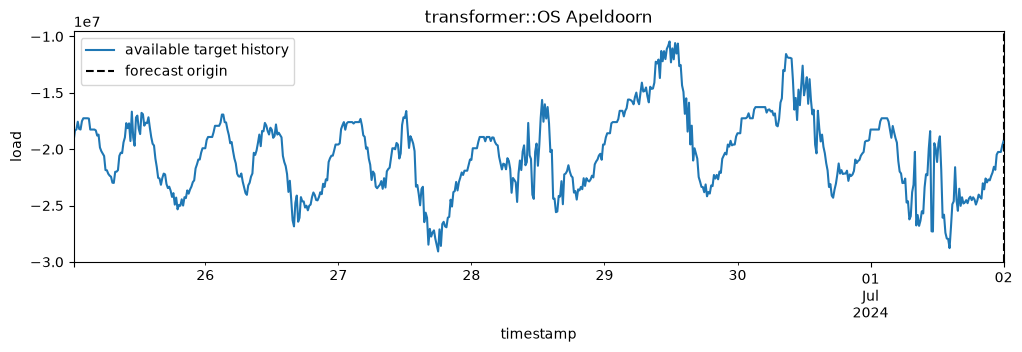

In [6]:
entity = frames[0]
origin = entity.target.index[len(entity.target) // 2]
past = entity.target.loc[:origin].tail(config.forecast.lookback_steps)
available_target = select_available_past_targets(past, origin, target_column=target_column)
future_index = pd.date_range(
    origin + pd.Timedelta(minutes=config.forecast.frequency_minutes),
    periods=config.forecast.horizon_steps,
    freq=f"{config.forecast.frequency_minutes}min",
    tz='UTC',
)
weather_vintage = select_latest_weather_forecast(entity.forecast_weather, origin, future_index)
print('origin:', origin)
print('target observations available:', available_target.notna().sum(), '/', len(available_target))
display(weather_vintage[['available_at', *config.covariates.weather]].head())
fig, ax = plt.subplots(figsize=(12, 3))
available_target.plot(ax=ax, label='available target history')
ax.axvline(origin, color='black', linestyle='--', label='forecast origin')
ax.legend(); ax.set_ylabel(target_column); ax.set_title(entity.entity.entity_id)

## Preprocessing contract

`build_cache_from_config` performs the following deterministic sequence: construct aligned origins; prepare each entity's target and covariates; reject an origin if any group member lacks finite required input; obtain frozen Chronos native quantiles and embeddings; apply the configured monotonicity repair; construct finite-cell PIT values; and save an xarray cache with test labels sealed. The next notebook executes that exact function, rather than reproducing this sequence in notebook code.